# Autoregressive CONUS Forecasting with GFS Analysis and Convnets

This notebook turns the NOAA GFS analysis archive from dynamical.org into a real spatiotemporal learning problem for convolutional networks.

The dataset provides a **global 0.25 degree analysis every hour** from **2021-05-01 to present**. It is not a forecast archive; it is a best-estimate reconstruction of past atmospheric state built by concatenating the first 6 hours of each historical GFS forecast. That makes it a useful training source for a data-driven surrogate that learns short-range evolution on a latitude-longitude grid.

We focus on the **CONUS** portion of the domain and pose the following task:

> Given the previous 24 hours of 6-hourly CONUS weather maps, predict the **next 6-hour atmospheric state**.

The state vector at each time consists of five near-surface fields:

1. `temperature_2m`
2. `pressure_reduced_to_mean_sea_level`
3. `precipitable_water_atmosphere`
4. `wind_u_10m`
5. `wind_v_10m`

This is a natural convolutional problem. Each sample is a stack of images on a common grid, and the evolution of fronts, pressure systems, and moisture plumes is strongly local in space.

We will:

1. Open the live GFS analysis Zarr store from dynamical.org
2. Extract a manageable CONUS subset
3. Build a supervised autoregressive dataset from short sequences of weather maps
4. Train a small fully convolutional network to predict the next state
5. Compare against a **persistence baseline**
6. Roll the model forward autoregressively and measure temperature error versus lead time

## Why 6-hourly data?

The GFS analysis product is hourly, but several variables on the catalog page are defined as averages or accumulations over the previous 1 to 6 hours and reset on the 6-hour forecast cycle. Using a 6-hour stride keeps the learning problem aligned with that native structure and reduces computational cost.

## Why this is interesting in Earth science

This notebook sits between two extremes:

- a classical numerical weather prediction model, which integrates PDEs explicitly
- a black-box tabular ML model, which ignores spatial structure

A convolutional forecaster learns local update rules directly from gridded data. It will not replace operational NWP, but it is an excellent setting for understanding how convnets represent atmospheric dynamics on maps.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import xarray as xr
from torch.utils.data import TensorDataset, DataLoader

rng = np.random.default_rng(42)
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cpu')


## 1. Experiment Configuration

These settings keep the notebook runnable on a laptop CPU. If you want a richer experiment, the first knobs to increase are the date range and the number of training epochs.

In [42]:
DATA_URL = "https://data.dynamical.org/noaa/gfs/analysis/latest.zarr"

VARIABLES = [
    'temperature_2m',
    'pressure_reduced_to_mean_sea_level',
    'precipitable_water_atmosphere',
    'wind_u_10m',
    'wind_v_10m',
]

START_DATE = '2025-01-01'
END_DATE   = '2025-02-15'

LAT_NORTH, LAT_SOUTH = 55.0, 20.0
LON_WEST,  LON_EAST  = -130.0, -60.0

TIME_STRIDE_HOURS = 6   # use every 6th analysis step
SPATIAL_STRIDE    = 2   # coarsen from 0.25° to 0.5° for a lighter experiment
CONTEXT_STEPS     = 4   # previous 24 hours at 6-hour cadence
ROLLOUT_STEPS     = 8   # 48-hour autoregressive forecast

TRAIN_FRACTION = 0.70
BATCH_SIZE     = 8
EPOCHS         = 8
LEARNING_RATE  = 1e-3
MODEL_WIDTH    = 128
N_BLOCKS       = 1


## 2. Load the GFS Analysis Data

The dynamical.org catalog page documents this dataset as:

- **Spatial domain:** global
- **Spatial resolution:** 0.25 degrees
- **Time resolution:** 1 hour
- **Time domain:** 2021-05-01 00:00 UTC to present

The same page gives the direct access pattern:

```python
xr.open_zarr("https://data.dynamical.org/noaa/gfs/analysis/latest.zarr")
```

We subset to CONUS, keep only the five variables above, and then stride in time and space so the notebook stays lightweight.

In [43]:
ds = xr.open_zarr(DATA_URL)[VARIABLES]

subset = (
    ds.sel(
        time=slice(START_DATE, END_DATE),
        latitude=slice(LAT_NORTH, LAT_SOUTH),
        longitude=slice(LON_WEST, LON_EAST),
    )
    .isel(
        time=slice(None, None, TIME_STRIDE_HOURS),
        latitude=slice(None, None, SPATIAL_STRIDE),
        longitude=slice(None, None, SPATIAL_STRIDE),
    )
    .load()
)

print(subset)


<xarray.Dataset> Size: 37MB
Dimensions:                             (time: 184, latitude: 71, longitude: 141)
Coordinates:
  * time                                (time) datetime64[ns] 1kB 2025-01-01 ...
  * latitude                            (latitude) float64 568B 55.0 ... 20.0
  * longitude                           (longitude) float64 1kB -130.0 ... -60.0
    spatial_ref                         int64 8B 0
Data variables:
    temperature_2m                      (time, latitude, longitude) float32 7MB ...
    pressure_reduced_to_mean_sea_level  (time, latitude, longitude) float32 7MB ...
    precipitable_water_atmosphere       (time, latitude, longitude) float32 7MB ...
    wind_u_10m                          (time, latitude, longitude) float32 7MB ...
    wind_v_10m                          (time, latitude, longitude) float32 7MB ...
Attributes:
    dataset_id:          noaa-gfs-analysis
    dataset_version:     0.1.0
    name:                NOAA GFS analysis
    description:     

We now have a small gridded dataset with dimensions `(time, latitude, longitude)`. The latitude coordinate in GFS is stored from north to south, so `slice(55, 20)` is the correct way to extract CONUS.

In [44]:
times = subset.time.values
lat = subset.latitude.values
lon = subset.longitude.values

state = np.stack([subset[var].values for var in VARIABLES], axis=1).astype(np.float32)
# state shape: (time, variable, latitude, longitude)

n_time, n_vars, n_lat, n_lon = state.shape
print(f"State tensor shape: {state.shape} = (time, variables, lat, lon)")
print(f"Date range after striding: {str(times[0])} to {str(times[-1])}")
print(f"Grid: {n_lat} latitudes x {n_lon} longitudes")


State tensor shape: (184, 5, 71, 141) = (time, variables, lat, lon)
Date range after striding: 2025-01-01T00:00:00.000000000 to 2025-02-15T18:00:00.000000000
Grid: 71 latitudes x 141 longitudes


## 3. Inspect a Single Atmospheric Snapshot

Before training anything, it is worth looking at the fields. This is one of the main habits to keep from scientific computing: always inspect the data in physical units before you normalize it away.

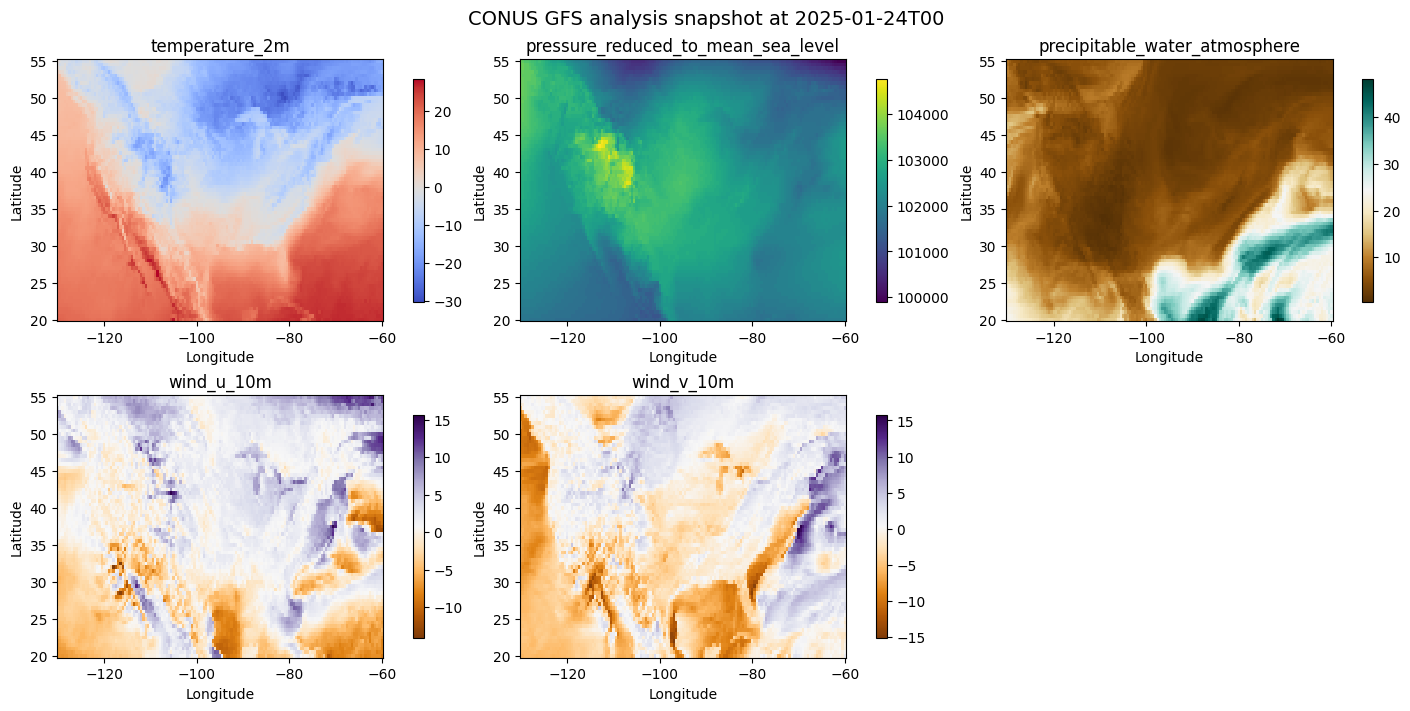

In [45]:
snapshot_idx = len(times) // 2
snapshot_time = np.datetime_as_string(times[snapshot_idx], unit='h')

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
axes = axes.ravel()
cmaps = ['coolwarm', 'viridis', 'BrBG', 'PuOr', 'PuOr']

for i, (var, cmap) in enumerate(zip(VARIABLES, cmaps)):
    pcm = axes[i].pcolormesh(lon, lat, state[snapshot_idx, i], shading='auto', cmap=cmap)
    axes[i].set_title(var)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    fig.colorbar(pcm, ax=axes[i], shrink=0.85)

axes[-1].axis('off')
fig.suptitle(f'CONUS GFS analysis snapshot at {snapshot_time}', fontsize=14)
plt.show()


## 4. Build the Forecasting Dataset

Let the atmospheric state at time $t$ be

$$
\mathbf{x}(t) \in \mathbb{R}^{C \times H \times W}, \qquad C = 5.
$$

We use the previous `CONTEXT_STEPS` states as input and ask the network to predict the next state:

$$
\hat{\mathbf{x}}(t+1) = f_\theta\big(\mathbf{x}(t-3), \mathbf{x}(t-2), \mathbf{x}(t-1), \mathbf{x}(t)\big).
$$

To feed this into a 2D CNN, we stack the time dimension into channels, so the input has shape

$$
(C \times L, H, W) = (5 \times 4, H, W) = (20, H, W).
$$

This is a standard trick in short-range spatiotemporal forecasting: treat recent history as a multi-channel image.

In [46]:
split_frame = int(TRAIN_FRACTION * n_time)
state_train = state[:split_frame]

state_mean = state_train.mean(axis=(0, 2, 3), keepdims=True)
state_std  = state_train.std(axis=(0, 2, 3), keepdims=True) + 1e-6
state_norm = (state - state_mean) / state_std


def make_supervised_samples(state_norm, context_steps):
    X, y, init_indices, target_indices = [], [], [], []
    n_time, n_vars, n_lat, n_lon = state_norm.shape

    for t in range(context_steps - 1, n_time - 1):
        history = state_norm[t - context_steps + 1 : t + 1]        # (context, vars, H, W)
        target  = state_norm[t + 1]                                # (vars, H, W)
        X.append(history.reshape(context_steps * n_vars, n_lat, n_lon))
        y.append(target)
        init_indices.append(t)
        target_indices.append(t + 1)

    return (
        np.stack(X).astype(np.float32),
        np.stack(y).astype(np.float32),
        np.asarray(init_indices),
        np.asarray(target_indices),
    )


X_all, y_all, init_idx, target_idx = make_supervised_samples(state_norm, CONTEXT_STEPS)
train_mask = target_idx < split_frame
val_mask   = target_idx >= split_frame

X_train = X_all[train_mask]
y_train = y_all[train_mask]
X_val   = X_all[val_mask]
y_val   = y_all[val_mask]

print(f"Total supervised samples: {len(X_all)}")
print(f"Training samples:         {len(X_train)}")
print(f"Validation samples:       {len(X_val)}")
print(f"Input shape per sample:   {X_train.shape[1:]}")
print(f"Target shape per sample:  {y_train.shape[1:]}")


Total supervised samples: 180
Training samples:         124
Validation samples:       56
Input shape per sample:   (20, 71, 141)
Target shape per sample:  (5, 71, 141)


We use a **temporal split**, not random shuffling. The model must forecast the future, not interpolate a mixed bag of historical samples. The normalization is also computed on the training portion only, which avoids leakage of validation statistics.

In [47]:
train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds   = TensorDataset(torch.tensor(X_val),   torch.tensor(y_val))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)


## 5. Define a Small Fully Convolutional Forecaster

We do not use pooling here because we want the output on the same grid as the input. The model is therefore a stack of same-resolution convolutions with residual blocks.

This is closer to a learned finite-difference update rule than to an image classifier: the network sees local stencils of nearby state and predicts the next state everywhere on the domain.

In [48]:
class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(width, width, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(width, width, kernel_size=3, padding=1),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class ConvForecaster(nn.Module):
    def __init__(self, in_channels, out_channels, width=32, n_blocks=4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, width, kernel_size=3, padding=1),
            nn.GELU(),
        )
        self.blocks = nn.Sequential(*[ResidualBlock(width) for _ in range(n_blocks)])
        self.head = nn.Conv2d(width, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.stem(x)
        x2 = self.blocks(x1)
        return self.head(x2) + x[:, :y_train.shape[1], :, :]  # Add skip connection from input to output


model = ConvForecaster(
    in_channels=CONTEXT_STEPS * n_vars,
    out_channels=n_vars,
    width=MODEL_WIDTH,
    n_blocks=N_BLOCKS,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")


Trainable parameters: 318,981


## 6. Train the Model

The loss is mean squared error on the normalized state. Because the variables have very different physical scales (Pa, °C, m s$^{-1}$, kg m$^{-2}$), standardizing before training is essential.

In [49]:
def evaluate_model(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            total_loss += loss.item() * xb.size(0)
            total += xb.size(0)
    return total_loss / total


loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'val_loss': []}
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    n_seen = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        running += loss.item() * xb.size(0)
        n_seen += xb.size(0)

    train_loss = running / n_seen
    val_loss = evaluate_model(model, val_loader, loss_fn)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | train {train_loss:.4f} | val {val_loss:.4f}")


Epoch 01/8 | train 0.3451 | val 0.2312
Epoch 02/8 | train 0.1695 | val 0.1685
Epoch 03/8 | train 0.1398 | val 0.1539
Epoch 04/8 | train 0.1310 | val 0.1461
Epoch 05/8 | train 0.1232 | val 0.1430
Epoch 06/8 | train 0.1188 | val 0.1346
Epoch 07/8 | train 0.1155 | val 0.1333
Epoch 08/8 | train 0.1118 | val 0.1313


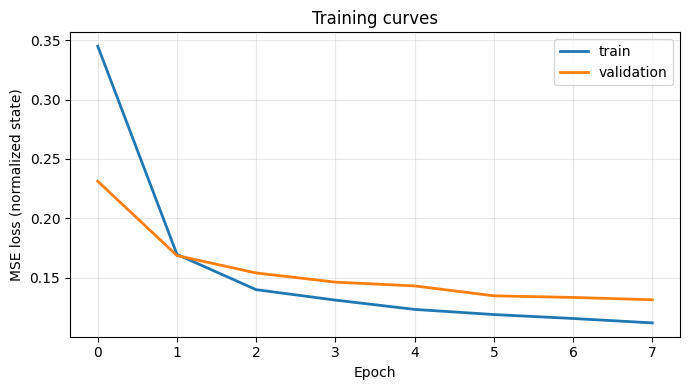

In [54]:
plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='train', linewidth=2)
plt.plot(history['val_loss'], label='validation', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE loss (normalized state)')
plt.title('Training curves')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 7. One-Step Forecast Skill vs Persistence

A serious forecasting notebook should always include a baseline. The natural baseline for short-range geophysical fields is **persistence**:

$$
\hat{\mathbf{x}}_{\mathrm{persist}}(t+1) = \mathbf{x}(t).
$$

If a learned model cannot beat persistence at 6-hour lead time, it is not doing useful forecasting.

In [55]:
with torch.no_grad():
    model.eval()
    pred_val_norm = model(torch.tensor(X_val).to(device)).cpu().numpy()

persist_val_norm = X_val[:, -n_vars:]  # the most recent state in the input history
true_val_norm = y_val

state_mean_ = state_mean[0]
state_std_  = state_std[0]

pred_val = pred_val_norm * state_std_ + state_mean_
persist_val = persist_val_norm * state_std_ + state_mean_
true_val = true_val_norm * state_std_ + state_mean_


def rmse(a, b, axis=None):
    return np.sqrt(np.mean((a - b) ** 2, axis=axis))

rows = []
for i, var in enumerate(VARIABLES):
    rmse_model = rmse(pred_val[:, i], true_val[:, i])
    rmse_persist = rmse(persist_val[:, i], true_val[:, i])
    rows.append((var, rmse_persist, rmse_model))

print(f"{'variable':35s} {'persistence RMSE':>18s} {'CNN RMSE':>12s}")
for var, r0, r1 in rows:
    print(f"{var:35s} {r0:18.3f} {r1:12.3f}")


variable                              persistence RMSE     CNN RMSE
temperature_2m                                   3.854        2.838
pressure_reduced_to_mean_sea_level             357.393      248.111
precipitable_water_atmosphere                    3.091        2.662
wind_u_10m                                       2.545        2.065
wind_v_10m                                       2.701        2.172


## 8. Autoregressive Rollout

Now we do the harder test. Starting from an observed history window, we roll the model forward repeatedly for 48 hours. At each step the model consumes its own previous prediction.

This is where errors compound, and it is the right place to ask whether the convnet has learned anything dynamical rather than merely denoising a one-step target.

In [56]:
def rollout_model(model, state_norm, init_index, context_steps, rollout_steps):
    seq = state_norm[init_index - context_steps + 1 : init_index + 1].copy()
    preds = []

    with torch.no_grad():
        model.eval()
        for _ in range(rollout_steps):
            x = torch.tensor(seq.reshape(1, context_steps * n_vars, n_lat, n_lon), dtype=torch.float32).to(device)
            yhat = model(x).cpu().numpy()[0]
            preds.append(yhat)
            seq = np.concatenate([seq[1:], yhat[None]], axis=0)

    return np.stack(preds)


def rollout_persistence(state_norm, init_index, rollout_steps):
    last_state = state_norm[init_index]
    return np.repeat(last_state[None], rollout_steps, axis=0)


val_init_indices = init_idx[val_mask]
rollout_starts = [t for t in val_init_indices if t + ROLLOUT_STEPS < len(state_norm)]
print(f"Validation rollout initializations available: {len(rollout_starts)}")


Validation rollout initializations available: 49


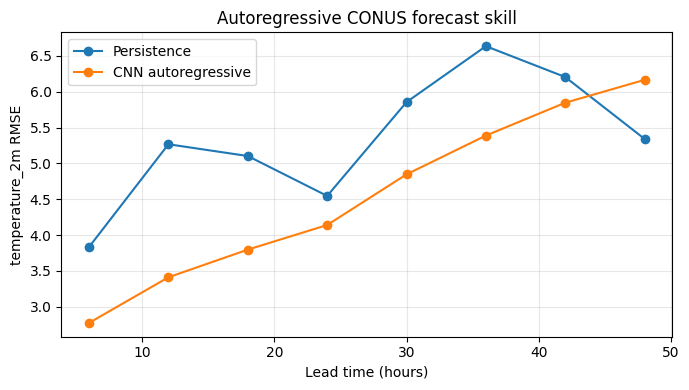

In [62]:
temp_var = 'temperature_2m'
temp_idx = VARIABLES.index(temp_var)
lead_hours = 6 * np.arange(1, ROLLOUT_STEPS + 1)

truth_rollouts = []
model_rollouts = []
persist_rollouts = []

for t0 in rollout_starts:
    truth_rollouts.append(state_norm[t0 + 1 : t0 + 1 + ROLLOUT_STEPS])
    model_rollouts.append(rollout_model(model, state_norm, t0, CONTEXT_STEPS, ROLLOUT_STEPS))
    persist_rollouts.append(rollout_persistence(state_norm, t0, ROLLOUT_STEPS))

truth_rollouts = np.stack(truth_rollouts)
model_rollouts = np.stack(model_rollouts)
persist_rollouts = np.stack(persist_rollouts)

truth_temp = truth_rollouts[:, :, temp_idx] * state_std_[temp_idx] + state_mean_[temp_idx]
model_temp = model_rollouts[:, :, temp_idx] * state_std_[temp_idx] + state_mean_[temp_idx]
persist_temp = persist_rollouts[:, :, temp_idx] * state_std_[temp_idx] + state_mean_[temp_idx]

rmse_roll_model = np.sqrt(np.mean((model_temp - truth_temp) ** 2, axis=(0, 2, 3)))
rmse_roll_persist = np.sqrt(np.mean((persist_temp - truth_temp) ** 2, axis=(0, 2, 3)))

plt.figure(figsize=(7, 4))
plt.plot(lead_hours, rmse_roll_persist, marker='o', label='Persistence')
plt.plot(lead_hours, rmse_roll_model, marker='o', label='CNN autoregressive')
plt.xlabel('Lead time (hours)')
plt.ylabel(f'{temp_var} RMSE')
plt.title('Autoregressive CONUS forecast skill')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 9. Visualize One 24-Hour Forecast

We now inspect one concrete rollout case at +24 hours. This is usually more informative than a single scalar metric because it shows *how* the model fails: phase errors, smearing of sharp fronts, amplitude damping, or spurious artifacts.

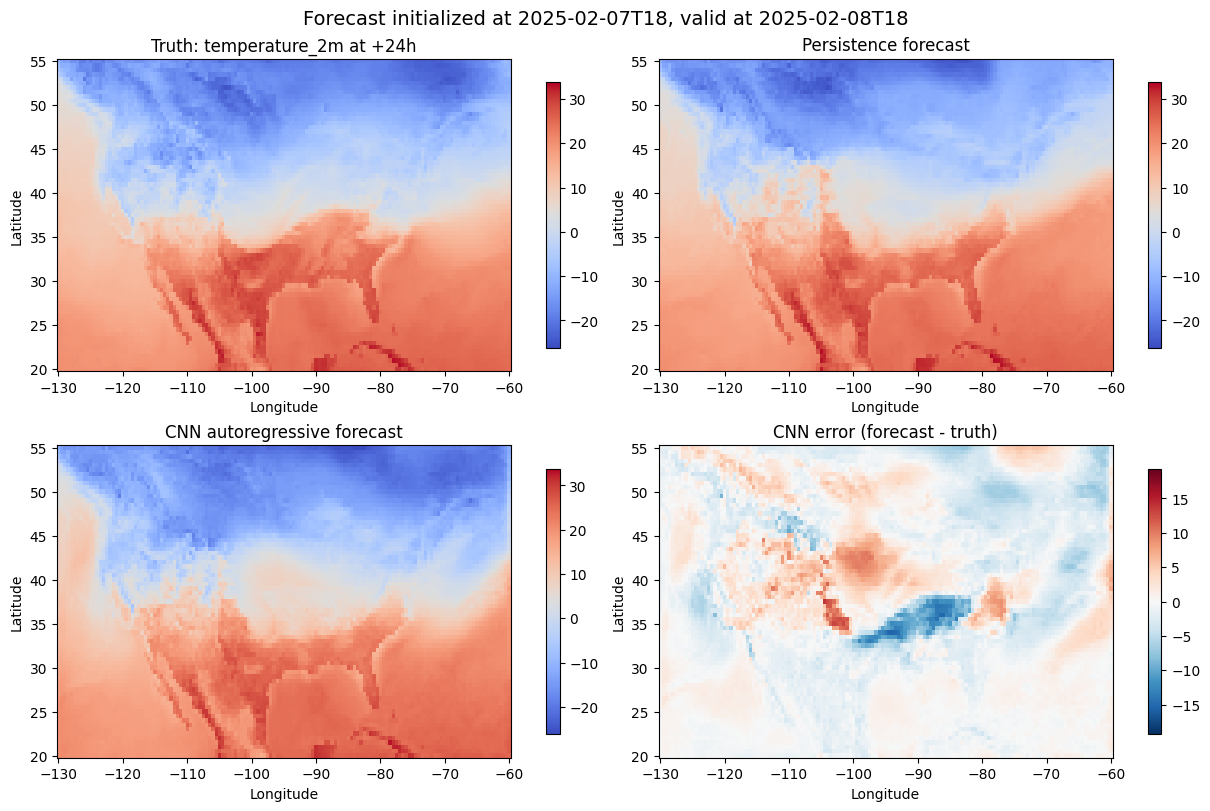

In [63]:
example_k = len(rollout_starts) // 2
example_t0 = rollout_starts[example_k]
lead_step = 4  # 24 hours

truth_24 = truth_temp[example_k, lead_step - 1]
persist_24 = persist_temp[example_k, lead_step - 1]
pred_24 = model_temp[example_k, lead_step - 1]

vmin = min(truth_24.min(), persist_24.min(), pred_24.min())
vmax = max(truth_24.max(), persist_24.max(), pred_24.max())
err_lim = max(np.abs(pred_24 - truth_24).max(), np.abs(persist_24 - truth_24).max())

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

panels = [
    (truth_24, f'Truth: {temp_var} at +24h', 'coolwarm', vmin, vmax),
    (persist_24, 'Persistence forecast', 'coolwarm', vmin, vmax),
    (pred_24, 'CNN autoregressive forecast', 'coolwarm', vmin, vmax),
    (pred_24 - truth_24, 'CNN error (forecast - truth)', 'RdBu_r', -err_lim, err_lim),
]

for ax, (field, title, cmap, lo, hi) in zip(axes.ravel(), panels):
    pcm = ax.pcolormesh(lon, lat, field, shading='auto', cmap=cmap, vmin=lo, vmax=hi)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    fig.colorbar(pcm, ax=ax, shrink=0.85)

init_time = np.datetime_as_string(times[example_t0], unit='h')
valid_time = np.datetime_as_string(times[example_t0 + lead_step], unit='h')
fig.suptitle(f'Forecast initialized at {init_time}, valid at {valid_time}', fontsize=14)
plt.show()


## Discussion

This is a deliberately modest model, but it already highlights several important ideas in scientific machine learning.

1. **Convolution is the right inductive bias for maps.** The same local filter can recognize baroclinic structure, wind shifts, or moisture gradients anywhere over CONUS.
2. **Persistence is a strong baseline.** At short lead times, many atmospheric fields change slowly, so beating persistence is nontrivial.
3. **Autoregressive rollout is much harder than one-step prediction.** Small phase and amplitude errors compound forward in time.
4. **This is not a full weather model.** We are forecasting only a tiny subset of the atmospheric state on a limited domain. There is no explicit conservation law, vertical structure, radiation, or boundary forcing.

Still, this notebook is a useful bridge from introductory convnets to real Earth-system forecasting because the data are real, the target is spatial, and the baseline is physically meaningful.

## Extensions

If you want to push this further, the most natural next steps are:

1. **Predict precipitation or cloud cover** as a separate target, using a weighted loss because extremes are rare
2. **Use a U-Net** so the model has a larger receptive field without losing spatial detail
3. **Train with a multi-step loss** instead of pure one-step teacher forcing
4. **Expand the state vector** with 500 hPa geopotential or relative humidity to better represent synoptic structure
5. **Compare against optical-flow style advection baselines** rather than only persistence
6. **Move from CONUS to a spherical or global architecture** if you want to avoid the distortions of a planar lat-lon crop